# 05 Visualisation

Inspect reconstructed trajectories and the latest available ML dataset without loading the full trajectories parquet into memory.

## Setup

Load config, preview a small trajectory sample, and prepare the final dataset path.

In [13]:
import os
import sys
import random
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from IPython.display import display

sys.path.append(os.path.abspath('..'))
from src.utils import load_config
import src.visualisation as visualisation_module

importlib.reload(visualisation_module)
TrajectoryVisualiser = visualisation_module.TrajectoryVisualiser

config = load_config('../configs/config.yaml')
paths = config['paths']
processed_dir = Path('..') / paths['processed_data_dir']
traj_path = processed_dir / paths['trajectories_file']
ml_data_path = processed_dir / paths['ml_dataset_file']
ml_labeled_fallback = processed_dir / 'ml_dataset_labeled.parquet'
active_ml_path = ml_data_path if ml_data_path.exists() else ml_labeled_fallback

trajectory_preview = pd.DataFrame()
trajectory_preview_ids = []

if traj_path.exists():
    traj_pf = pq.ParquetFile(traj_path)
    preview_batches = traj_pf.iter_batches(batch_size=100_000)
    first_batch = next(preview_batches, None)
    if first_batch is not None:
        trajectory_preview = first_batch.to_pandas()
        if 'trajectory_id' in trajectory_preview.columns:
            trajectory_preview_ids = [tid for tid in trajectory_preview['trajectory_id'].dropna().astype(str).unique().tolist() if tid]
        print(f'Previewed {len(trajectory_preview):,} trajectory rows from {traj_path}.')
        print(f'Found {len(trajectory_preview_ids):,} unique trajectory_ids in the preview batch.')
        display(trajectory_preview.head())
    else:
        print(f'{traj_path} exists but contains no rows.')
else:
    print(f'No trajectories found at {traj_path}. Run notebook 02 first.')


Previewed 100,000 trajectory rows from ..\data\processed\trajectories.parquet.
Found 5,659 unique trajectory_ids in the preview batch.


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,...,vertical_rate,sensors,geo_altitude,squawk,spi,position_source,timestamp,sample_date,sample_hour,trajectory_id
0,a0faf3,AAL2235,None,1.651450e+09,1.651450e+09,-97.268129,33.237925,4046.22,False,219.441574,...,9.10336,None,4191.00,NaN,False,None,1651449600,2022-05-02,0,a0faf3_0
1,a88df0,NKS1301,None,1.651450e+09,1.651450e+09,-92.791958,34.588406,10363.20,False,201.905999,...,0.00000,None,10690.86,7177,False,None,1651449600,2022-05-02,0,a88df0_0
2,a92367,UAL1989,None,1.651450e+09,1.651450e+09,-92.772102,34.569831,10668.00,False,246.474517,...,0.00000,None,10995.66,2707,False,None,1651449600,2022-05-02,0,a92367_0
3,a992cf,SKW3207,None,1.651450e+09,1.651450e+09,-97.366613,33.168283,1653.54,False,131.683596,...,-6.82752,None,1676.40,2104,False,None,1651449600,2022-05-02,0,a992cf_0
4,a9ccb0,SWA1212,None,1.651450e+09,1.651450e+09,-91.966610,34.310815,11887.20,False,268.325824,...,0.00000,None,12207.24,2303,False,None,1651449600,2022-05-02,0,a9ccb0_0


## Trajectory Map

Pick one trajectory id from the preview batch, then stream only matching rows from the parquet for mapping.

In [14]:
if traj_path.exists() and trajectory_preview_ids:
    random_traj = random.choice(trajectory_preview_ids)
    print(f'Displaying trajectory: {random_traj}')

    selected_parts = []
    for batch in pq.ParquetFile(traj_path).iter_batches(batch_size=100_000):
        batch_df = batch.to_pandas()
        if 'trajectory_id' not in batch_df.columns:
            continue
        matched = batch_df[batch_df['trajectory_id'].astype(str) == random_traj]
        if not matched.empty:
            selected_parts.append(matched)

    if selected_parts:
        df_traj_single = pd.concat(selected_parts, ignore_index=True)
        print(f'Loaded {len(df_traj_single):,} rows for trajectory {random_traj}.')
        m = TrajectoryVisualiser.generate_interactive_map(df_traj_single, trajectory_ids=[random_traj])
        display(m)
    else:
        print('Could not find rows for the sampled trajectory id.')
else:
    print('No valid trajectory preview is available yet. Run notebook 02 first.')


Displaying trajectory: aaf001_0
Loaded 288 rows for trajectory aaf001_0.


## Label Distribution

Use the final validated dataset when available, otherwise fall back to the labeled dataset created in notebook 04.

In [15]:
df_ml = pd.DataFrame()

if active_ml_path.exists():
    df_ml = pd.read_parquet(active_ml_path)
    print(f'Loaded ML dataset from {active_ml_path}')
    print(f'ML Dataset Size: {len(df_ml):,} rows')
    display(df_ml.head())
else:
    print('No ML dataset found yet. Run notebook 04, or weather/label/validate in main.py, first.')


Loaded ML dataset from ..\data\processed\ml_dataset.parquet
ML Dataset Size: 83,289 rows


,flight_key,region,source_dataset,scheduled_dep,scheduled_arr,origin,destination,cancelled,flight_duration,trajectory_length,...,weather_confidence,match_quality,label_source,match_score_minutes,match_anchor,match_confidence,training_eligible,feature_quality_score,delay_minutes,label
0,B633_20220501,US,bts,2022-05-01 16:00:00+00:00,2022-05-01 22:43:00+00:00,KBOS,KSFO,0,1660.0,0.000000,...,None,multi_anchor_service_day<180m,bts_verified,112.666667,arrival,0.121622,False,0.529412,6.0,Normal
1,UA1540_20220501,US,bts,2022-05-01 16:35:00+00:00,2022-05-01 22:05:00+00:00,KSFO,KRSW,0,590.0,48.380599,...,None,multi_anchor_service_day<180m,bts_verified,125.000000,arrival,0.113514,True,0.705882,22.0,Late
2,WN606_20220501,US,bts,2022-05-01 17:25:00+00:00,2022-05-01 21:50:00+00:00,KMIA,KDEN,0,980.0,140.128264,...,None,multi_anchor_service_day<180m,bts_verified,146.500000,arrival,0.101695,True,0.705882,-5.0,Normal
3,UA1172_20220501,US,bts,2022-05-01 17:40:00+00:00,2022-05-02 00:22:00+00:00,KBOS,KSFO,0,700.0,17.937088,...,None,multi_anchor_service_day<180m,bts_verified,10.166667,arrival,0.299287,True,0.705882,-1.0,Normal
4,WN1083_20220501,US,bts,2022-05-01 17:45:00+00:00,2022-05-01 23:10:00+00:00,PHNL,KSAN,0,3120.0,528.915144,...,None,multi_anchor_service_day<180m,bts_verified,121.500000,arrival,0.330579,True,0.705882,8.0,Normal


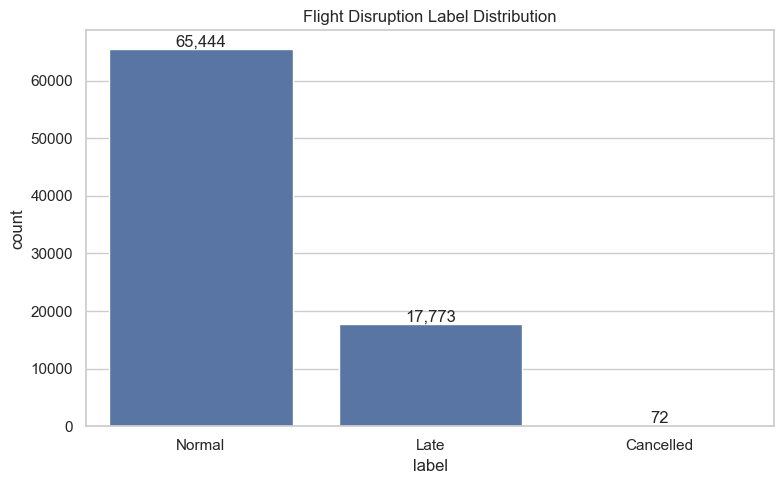

In [16]:
if not df_ml.empty and 'label' in df_ml.columns:
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df_ml, x='label', order=df_ml['label'].value_counts().index)
    plt.title('Flight Disruption Label Distribution')

    for patch in ax.patches:
        ax.annotate(
            f"{int(patch.get_height()):,}",
            (patch.get_x() + patch.get_width() / 2.0, patch.get_height()),
            ha='center',
            va='center',
            xytext=(0, 5),
            textcoords='offset points',
        )

    plt.tight_layout()
    plt.show()
else:
    print('No label column is available yet for plotting.')
